In [1]:
import numpy as np
from PIL import Image
from datasets import load_dataset
import matplotlib.pyplot as plt

ds = load_dataset("nikolkoo/SatelliteSegmentation")

ds

DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 790
    })
})

# Problem 1: Exploration

## Sub-Question 1 Response:

The dataset is a dictionary containing 790 pairs of images. These pairs have 1 mask and 1 RGB satellite image each. Every image in every pair is the same size of 256 pixels by 256 pixels.

In [2]:
for k, v in ds['train'][0].items():
    if hasattr(v, 'size'):
        print(f"{k}: PIL Image, size={v.size}, mode={v.mode}")

image: PIL Image, size=(256, 256), mode=RGB
mask: PIL Image, size=(256, 256), mode=L


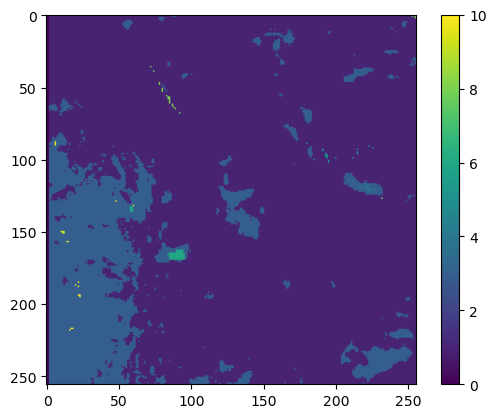

In [3]:
sample = ds['train'][0]['mask']
sample = np.array(sample)
sample = sample//10

plt.imshow(sample)
plt.colorbar()


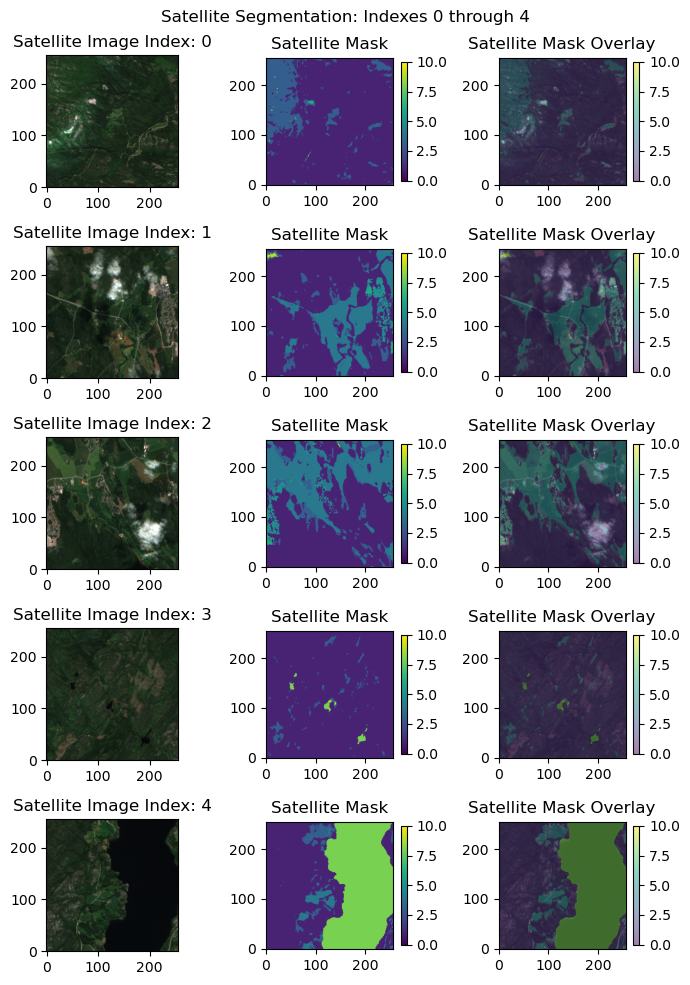

In [4]:
fig, ax = plt.subplots(5, 3, figsize=(7, 10))


for idx in range(0, 5):
    ax[idx][0].imshow(np.array(ds['train'][idx]['image']))
    ax[idx][0].invert_yaxis()
    ax[idx][0].set_title(f"Satellite Image Index: {idx}")


    im = ax[idx][1].imshow(np.array(ds['train'][idx]['mask'])//10, vmin=0, vmax=10)
    ax[idx][1].invert_yaxis()
    fig.colorbar(im, ax=ax[idx][1], shrink=0.9)
    ax[idx][1].set_title("Satellite Mask")

    ax[idx][2].imshow(np.array(ds['train'][idx]['image']))
    im2 = ax[idx][2].imshow(np.array(ds['train'][idx]['mask'])//10, alpha=0.5, vmin=0, vmax=10)
    ax[idx][2].invert_yaxis()
    fig.colorbar(im2, ax=ax[idx][2], shrink=0.9)
    ax[idx][2].set_title("Satellite Mask Overlay")


plt.suptitle("Satellite Segmentation: Indexes 0 through 4")
plt.tight_layout()
plt.show()

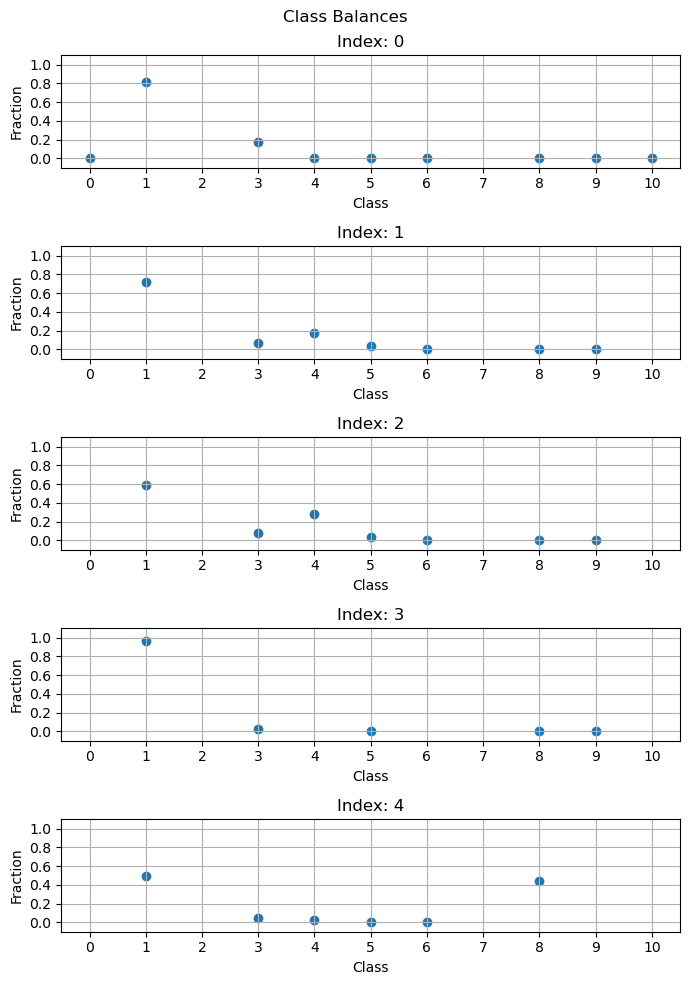

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(7, 10))


for idx in range(0, 5):
    arr = np.array(ds['train'][idx]['mask'])//10
    max = arr.flatten().shape[0]
    unq = np.unique(arr)
    cnts = np.array([])
    for val in unq:
        cnt = (arr == val).sum()
        cnts = np.append(cnts, cnt)

    cnts = cnts / max


    ax[idx].scatter(unq, cnts)
    ax[idx].set_xlim(-0.5, 10.5)
    ax[idx].set_xticks(np.arange(0, 11, 1))
    ax[idx].set_xticklabels(np.arange(0, 11, 1))
    ax[idx].set_ylim(-0.1, 1.1)
    ax[idx].set_yticks(np.arange(0, 1.2, 0.2))

    ax[idx].grid()
    ax[idx].set_title(f"Index: {idx}")
    ax[idx].set_xlabel("Class")
    ax[idx].set_ylabel("Fraction")


plt.suptitle("Class Balances")
plt.tight_layout()
plt.show()

## Sub-question 2 response:

With just the first 5 map examples the algorithm will learn only the classes it is presented with. For example from this subset the algorithm should be able to learn class 1 fairly easily as there is a lot of examples for it to learn from, but class 0 will be much more difficult as it practically doesn't show up. (except for the index 0 case) In the above graphs if a class doesn't have a plot marker, it doesn't appear in the indexes example.

In [6]:
np.array(ds['train']['mask'][0]).shape

(256, 256)

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import numpy as np

class SatelliteSegmentation(Dataset):
    def __init__(self, data_list, image_size=(256, 256)):
        """
        Args:

        """
        self.data_list = data_list
        self.image_size = image_size
    def __len__(self):
        return len(self.data_list)
    def _to_tensor_image(self, image):

        if isinstance(image, np.ndarray):
            image = np.array(image)
            image = torch.from_numpy(image)
        elif not isinstance(image, torch.Tensor):
            image = np.array(image)
            image = torch.tensor(image)


        if image.ndim == 3:
            if image.shape[-1] == 3:
                image = image.permute(2,0,1) # Convert H, W, 3 to 3, H, W
            elif image.shape[0] == 3:
                pass
            else:
                raise ValueError(f"Bad Image Shape: {image.shape}")
        else:
            raise ValueError(f"Bad Image Dimensions [NEED 3]: {image.shape}")

        if image.max() > 1.0:
            image = image / 255.0 # RGB Scaling from 0 to 255 to 0 to 1

        image = F.interpolate(image.unsqueeze(0), size=self.image_size, mode="bilinear", align_corners=False).squeeze(0)
        return image

    def _to_tensor_mask(self, mask):
        mask = np.array(mask) // 10
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask)
        elif not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask)

        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.squeeze(-1)
        elif mask.ndim == 3 and mask.shape[0] == 1:
            mask = mask.squeeze(-1)

        if mask.ndim != 2:
            raise ValueError(f"Mask must have shape of H,W and got {mask.shape}")

        mask = mask.unsqueeze(0).unsqueeze(0).to(torch.float32)
        mask = F.interpolate(mask, size=self.image_size, mode="nearest", align_corners=None).squeeze(0).squeeze(0)
        return mask

    def __getitem__(self, idx):
        sample = self.data_list[idx]
        image = self._to_tensor_image(sample['image'])
        mask = self._to_tensor_mask(sample['mask'])
        return image, mask


In [8]:
data_pairs = ds['train']
full_dataset = SatelliteSegmentation(data_pairs, image_size=(256, 256))

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

generator = torch.Generator().manual_seed(42)  # Answer to life, the universe, and everything

train_dataset, val_dataset = random_split(full_dataset, (train_size, val_size), generator=generator)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [9]:
print(f"Total samples: {total_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Check one batch
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)   # (B, 3, 256, 256)
print("Mask batch shape:", masks.shape)     # (B, 256, 256)
print("Image dtype:", images.dtype)         # torch.float32
print("Mask dtype:", masks.dtype)           # torch.int64


Total samples: 790
Training samples: 632
Validation samples: 158
Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32


# Problem 2: Model Design for U-Net Architecture

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as f

class DoubleConv(nn.Module):
    """
    Uses 2 consecutie convolutions (3x3 filter) and follows it with a normalization over the batch and uses ReLU activation (as seen in class). Spatial dimension preservation by adding padding=1.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__() # Makes sure things are correctly pulled in from __init__ in this class.
        self.block = (
            nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1,bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True), # End of First Pass

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1,bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) # End of Second pass
            ))

    def forward(self, x):
        return self.block(x)

class down_sample(nn.Module):
    """
    This class only handles downsampling.

    MaxPool -> Double Convolution
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.block(x)


class up_sample(nn.Module):
    """
    This Class only handles upsampling.

    Transpose -> skip connection -> double convolution
    """

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)

        if diff_y != 0 or diff_x != 0:
            x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y// 2, diff_y - diff_y // 2])

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

class UNET(nn.Module):
    """
    U-Net Architecture

    In - (B, 3, H, W)

    Out - (B, C, H, W) tensor of logits: Per Pixel!
    """

    def __init__(self, in_channels = 3, num_classes = 2, base_channels = 64):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base_channels)

        self.down1 = down_sample(base_channels, base_channels * 2)
        self.down2 = down_sample(base_channels * 2, base_channels * 4)
        self.down3 = down_sample(base_channels * 4, base_channels * 8)
        self.down4 = down_sample(base_channels * 8, base_channels * 16)

        self.up1 = up_sample(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = up_sample(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = up_sample(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = up_sample(base_channels * 2, base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encode:
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)


        # Decode
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.out_conv(x) # Output (Hopefully B,C,H,W
        return logits


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = 11

model = UNET(in_channels = 3, num_classes = classes, base_channels=4).to(device)

x = torch.randn(8, 3, 256, 256).to(device)  # Check that the model works with random fill numbers
y = model(x)

print("Input Shape:", x.shape)   # B, 3, H, W
print("Output Shape:", y.shape)  # B, C, H, W

# For Question response calculate the total number of trainable params:

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTrainable Params: {num_params}")

Input Shape: torch.Size([8, 3, 256, 256])
Output Shape: torch.Size([8, 11, 256, 256])

Trainable Params: 122143


## Question 2 Justifications

The U-Net architecture is appropriate for sematic segmentation as it predicts a class label for every individual pixel. Thus, each pixel can be identified separately rather than having one single label for the entire image (as a normal CNN would). The skip connections are very critical as they pass high-resolution feature information from the encoder directly to the decoder. This helps to recover fine-resolution boundaries that would be lost through the pooling stage of the convolution.

The total number of thr trainable parameters in my model is 122,143 which was given from the above section.

# Problem 3: Training

In [12]:
def compute_class_weights(dataloader, classes, device):
    class_counts = torch.zeros(classes, dtype=torch.float32)

    for _, masks in dataloader:
        masks = masks.view(-1).to(torch.int)
        counts = torch.bincount(masks, minlength=classes).to(torch.float32)
        class_counts += counts

    class_counts[class_counts == 0] = 1.0

    total_pixels = sum(class_counts)

    weights = total_pixels / (classes * class_counts)  # Inverse weighting that was wanted in the problem: total pixels / C*pixels of class C

    weights = weights / (weights.sum() * classes) # Normalize Weights (Implement if needed)

    return weights.to(torch.float32).to(device)

class_weights = compute_class_weights(train_loader, classes, device)
print(f"The Class Weights are: {class_weights}")

class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


def compute_mean_IoU(logits, masks, classes):
    preds = torch.argmax(logits, dim=1)

    ious = []

    for cls in range(classes):
        pred_cls = (preds == cls)
        true_cls = (masks == cls)

        intersection = (pred_cls & true_cls).sum().item()
        union = (pred_cls | true_cls).sum().item()

        if union > 0:
            ious.append(intersection / union)

        if len(ious) == 0:
            return 0.0

        return sum(ious) / len(ious)

train_loss = []
val_loss = []
val_mIoU = []

epochs = 500  # Have at least 20 epochs for training

# Training Loop


best_val_loss = float("inf")
patience = 10
epochs_no_improve = 0
best_epoch = -1

best_model_path = "best_unet.pt"




for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.long)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    train_loss.append(epoch_loss)

    # Validation Loop

    model.eval()
    running_val_loss = 0.0
    running_val_mIoU = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.long)

            logits = model(images)
            loss = criterion(logits, masks)

            running_val_loss += loss.item() * images.size(0)
            running_val_mIoU += compute_mean_IoU(logits, masks, classes) * images.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_mIoU = running_val_mIoU / len(val_loader.dataset)

        val_loss.append(epoch_val_loss)
        val_mIoU.append(epoch_val_mIoU)

        print(f"----------------------------------------"
              f"Epoch           : {epoch +1}/{epochs}\n"
              f"Train Loss      : {epoch_loss:.4f}\n"
              f"Validation Loss : {epoch_val_loss:.4f}\n"
              f"Validation mIoU : {epoch_val_mIoU:.4f}")

    if epoch_val_loss < best_val_loss - 1e-4:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0

        # Save best model
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved")
        print(f"Loss = {epoch_val_loss:.4f}")

    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # Stop if no improvement for 'patience' epochs
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        best_epoch = epoch
        break


The Class Weights are: tensor([2.6760e-04, 8.3803e-08, 2.3092e-03, 6.5584e-07, 8.3700e-07, 1.6031e-06,
        3.5088e-05, 8.8078e-02, 6.8241e-07, 7.4273e-05, 1.4145e-04],
       device='cuda:0')
----------------------------------------Epoch           : 1/500
Train Loss      : 2.5121
Validation Loss : 2.4503
Validation mIoU : 0.0008
New best model saved
Loss = 2.4503
----------------------------------------Epoch           : 2/500
Train Loss      : 2.4260
Validation Loss : 2.3891
Validation mIoU : 0.0023
New best model saved
Loss = 2.3891
----------------------------------------Epoch           : 3/500
Train Loss      : 2.3649
Validation Loss : 2.3597
Validation mIoU : 0.0029
New best model saved
Loss = 2.3597
----------------------------------------Epoch           : 4/500
Train Loss      : 2.3254
Validation Loss : 2.3363
Validation mIoU : 0.0020
New best model saved
Loss = 2.3363
----------------------------------------Epoch           : 5/500
Train Loss      : 2.2941
Validation Loss : 2

## Problem 3 Plots

Loaded best model based on validation mIoU
Epoch Array: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103]
Training Loss Array: [2.5121326205096666, 2.4259647689288175, 2.364946754672859, 2.3253757832925532, 2.294113850291771, 2.2610466389716426, 2.232521138613737, 2.221856511091884, 2.19719904283934, 2.188991623588755, 2.1671461621417274, 2.135396195363395, 2.1328106635733497, 2.101312205761294, 2.0859344548816923, 2.0712109336370155, 2.0579393438146085, 2.0220170398301716, 2.0260201692581177, 2.00646465488627, 1.9913152999515775, 1.9666051140314416, 1.9372950490516951, 1.9408732139611546, 1.9062793979161903, 1.890758884103

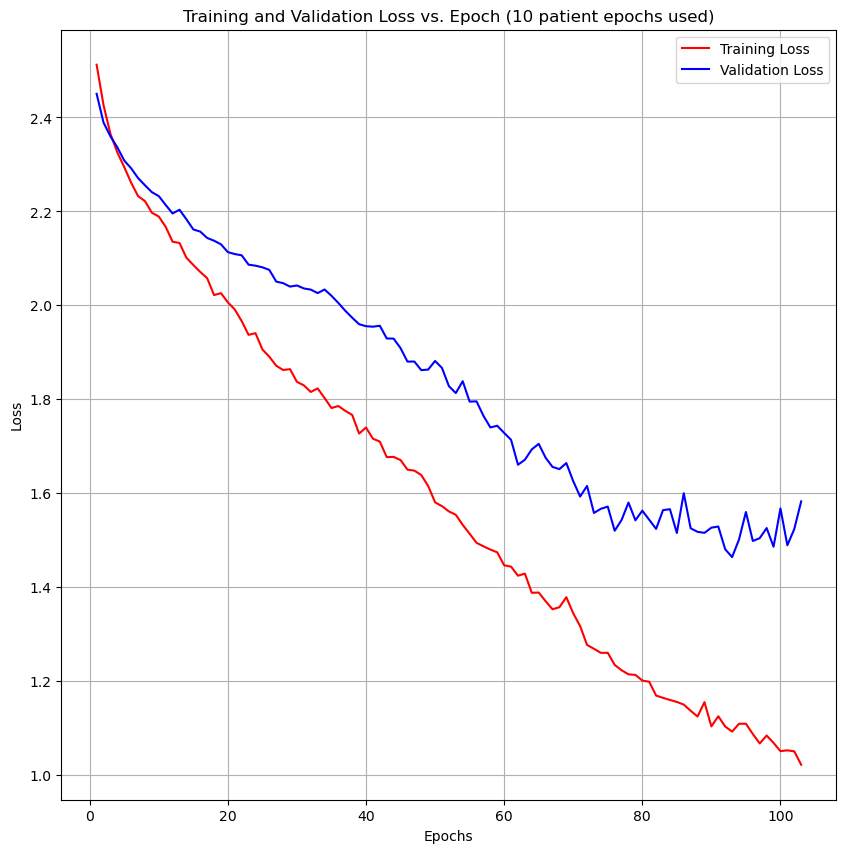

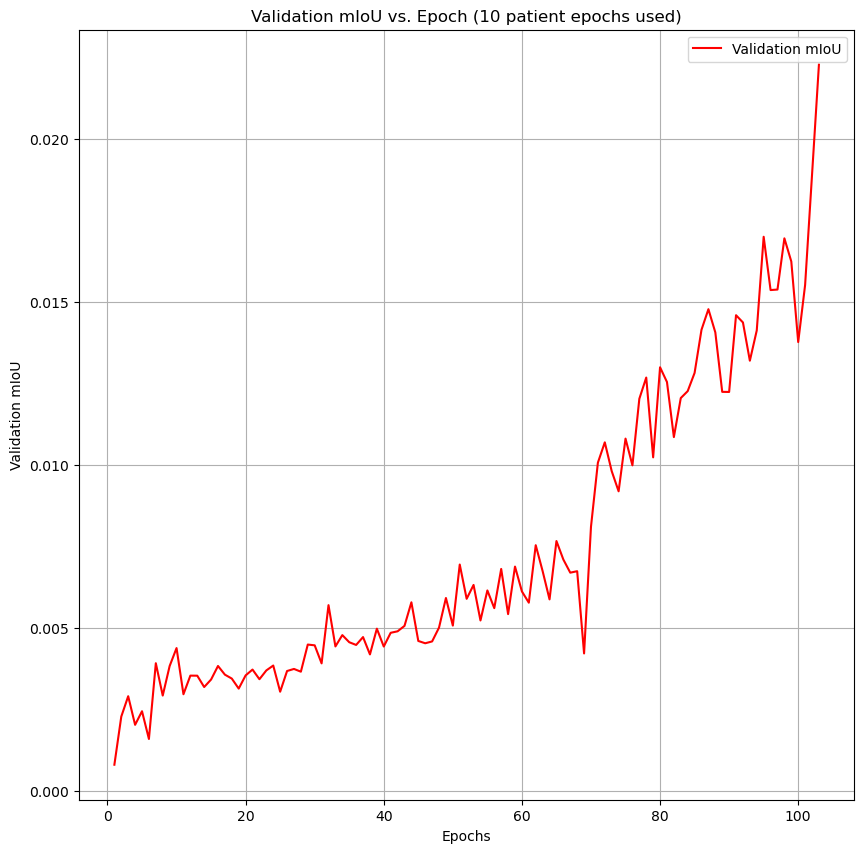

In [13]:
model.load_state_dict(torch.load(best_model_path))
print("Loaded best model based on validation mIoU")

epchs = np.arange(1, (best_epoch+2), 1)

print(f"Epoch Array: {epchs}")
print(f"Training Loss Array: {train_loss}")
print(f"Val Loss Array: {val_loss}")
print(f"Validation mIoU Array: {val_mIoU}")

plt.figure(figsize = (10,10))
plt.plot(epchs, train_loss, 'r', label = 'Training Loss')
plt.plot(epchs, val_loss, 'b', label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss vs. Epoch ({patience} patient epochs used)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize = (10,10))
plt.plot(epchs, val_mIoU, 'r', label = 'Validation mIoU')
plt.xlabel('Epochs')
plt.ylabel('Validation mIoU')
plt.title(f'Validation mIoU vs. Epoch ({patience} patient epochs used)')
plt.legend()
plt.grid(True)
plt.show()


## Problem 3 Discussion:

The model shows some signs of overfitting. We can determine this from the fact that training loss continues to fall while validation loss slows. This is also seen in the mIoU as they remain very small. This is still noted as happening even after making a smaller UNET, and decreasing the learning rate.

# Problem 4: Evaluation and Interpretation
---
## Problem 4a

In [14]:
def evaluate_IoU(model, dataloader, classes, deice):
    model.eval()

    tp = torch.zeros(classes, dtype=torch.float, device=device)
    fp = torch.zeros(classes, dtype=torch.float, device=device)
    fn = torch.zeros(classes, dtype=torch.float, device=device)

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.long)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            for c in range(classes):
                pred_c = (preds == c)
                true_c = (masks == c)

                tp[c] += (pred_c & true_c).sum()
                fp[c] += (pred_c & ~true_c).sum()
                fn[c] += (~pred_c & true_c).sum()

            denom = tp + fp + fn

            per_class_IoU = torch.zeros(classes, dtype=torch.float, device=device)

            valid = denom > 0
            per_class_IoU[valid] = tp[valid] / denom[valid]

            mIoU = per_class_IoU.mean().item()

            return (
                per_class_IoU.cpu().numpy(),
                mIoU,
                tp.cpu().numpy(),
                fp.cpu().numpy(),
                fn.cpu().numpy()
            )


In [15]:
model = model.to(device)

per_class_IoU, mIoU, tp, fp, fn = evaluate_IoU(model, val_loader, classes, device)

print("Per-Class IoU:")
for c, IoU in enumerate(per_class_IoU):
    print(f"Class {c}: {IoU:.4f}")

print(f"\n Validation mIoU: {mIoU:.4f}")

Per-Class IoU:
Class 0: 0.0000
Class 1: 0.1531
Class 2: 0.0000
Class 3: 0.2109
Class 4: 0.2316
Class 5: 0.2872
Class 6: 0.1099
Class 7: 0.0000
Class 8: 0.7955
Class 9: 0.0095
Class 10: 0.0000

 Validation mIoU: 0.1634


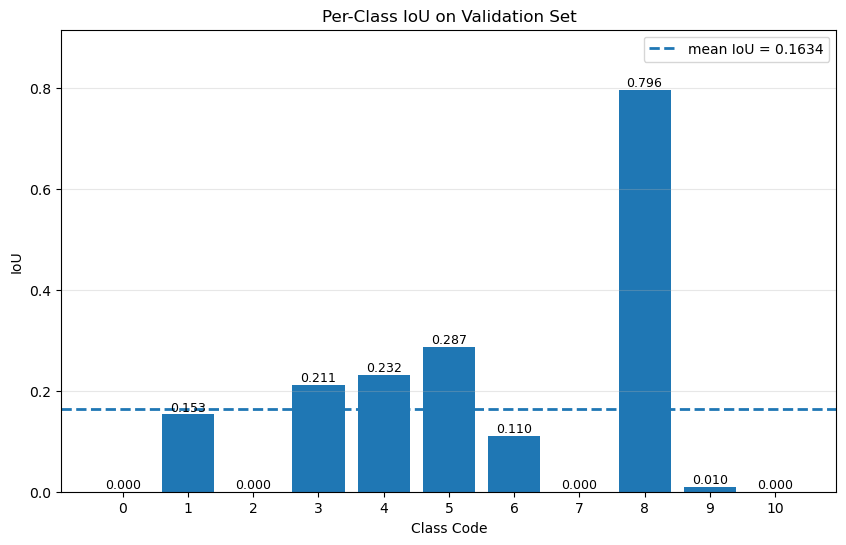

In [16]:
class_codes = [str(i) for i in range(classes)]  # or replace with real class names

plt.figure(figsize=(10, 6))
bars = plt.bar(class_codes, per_class_IoU)



plt.axhline(mIoU, linestyle='--', linewidth=2, label=f"mean IoU = {mIoU:.4f}")

plt.xlabel("Class Code")
plt.ylabel("IoU")
plt.title("Per-Class IoU on Validation Set")

y_max = float(np.max([0.05, np.max(per_class_IoU) * 1.15]))

plt.ylim(0, y_max)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# label each bar with value
for bar, iou in zip(bars, per_class_IoU):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{iou:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

#### Percentages of each type of class (for discussion)

In [17]:
class_counts = torch.zeros(classes, dtype=torch.float64)
total_pixels = 0

for images, masks in full_dataset:   # or full_dataset loader
    masks = masks.view(-1).to(torch.int)           # flatten all pixels

    counts = torch.bincount(masks, minlength=classes).to(torch.float64)

    class_counts += counts
    total_pixels += masks.numel()

# fractions
class_fractions = class_counts / total_pixels

# print results
for c in range(classes):
    print(f"Class {c}: fraction (percentage) = {class_fractions[c] * 100:.3f} "
          f"(count = {int(class_counts[c])})")

Class 0: fraction (percentage) = 0.021 (count = 10752)
Class 1: fraction (percentage) = 70.617 (count = 36560738)
Class 2: fraction (percentage) = 0.003 (count = 1626)
Class 3: fraction (percentage) = 9.274 (count = 4801317)
Class 4: fraction (percentage) = 7.382 (count = 3821687)
Class 5: fraction (percentage) = 3.778 (count = 1955765)
Class 6: fraction (percentage) = 0.178 (count = 92350)
Class 7: fraction (percentage) = 0.000 (count = 49)
Class 8: fraction (percentage) = 8.608 (count = 4456426)
Class 9: fraction (percentage) = 0.078 (count = 40555)
Class 10: fraction (percentage) = 0.062 (count = 32175)


## Problem 4a Discussion:
From the bar chart we can see that the model is learning some of the classes but not all of them. Specifically, class 1, 4, 5, and 8 are all above the mean, but classes 0, 2, 3, 6, 7, 9, and 10 are all bellow the mean intersection over union. These are similar to the classes that were mentioned in problem 1. For example class 1 shows up very frequently in the dataset so the model is able to learn class 1 detection fairly easily.

---
## Problem 4b

In [18]:
def unnormalize_image(img:torch.Tensor):
    img = img.detach().cpu().clone()

    img = img.permute(1,2,0).numpy()

    return np.clip(img, 0, 1)


def sample_miou(pred_mask, true_mask, num_classes=11):

    if isinstance(pred_mask, np.ndarray):
        pred_mask = torch.from_numpy(pred_mask)
    if isinstance(true_mask, np.ndarray):
        true_mask = torch.from_numpy(true_mask)

    pred_mask = pred_mask.cpu()
    true_mask = true_mask.cpu()

    IoUs = []

    for c in range(num_classes):
        pred_c = (pred_mask == c)
        true_c = (true_mask == c)

        union = (pred_c | true_c).sum().item()
        if union > 0:
            intersection = (pred_c & true_c).sum().item()
            IoUs.append(intersection / union)

    if len(IoUs) == 0:
        return 0.0

    return sum(IoUs) / len(IoUs)


def visualize_predictions(model, dataloader, device, num_classes=11, num_samples=4):
    """
    Visualize at least num_samples validation examples.
    """
    model.eval()

    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device).float()
            masks = masks.to(device).long()

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            batch_size = images.shape[0]

            for i in range(batch_size):
                image_disp = unnormalize_image(images[i])
                true_mask = masks[i].cpu().numpy()
                pred_mask = preds[i].cpu().numpy()

                miou = sample_miou(pred_mask, true_mask, num_classes=num_classes)

                plt.figure(figsize=(15, 5))

                plt.subplot(1, 3, 1)
                plt.imshow(image_disp)
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(true_mask, vmin=0, vmax=num_classes - 1)
                plt.title("Ground Truth Mask")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred_mask, vmin=0, vmax=num_classes - 1)
                plt.title(f"Predicted Mask\nmIoU = {miou:.4f}")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

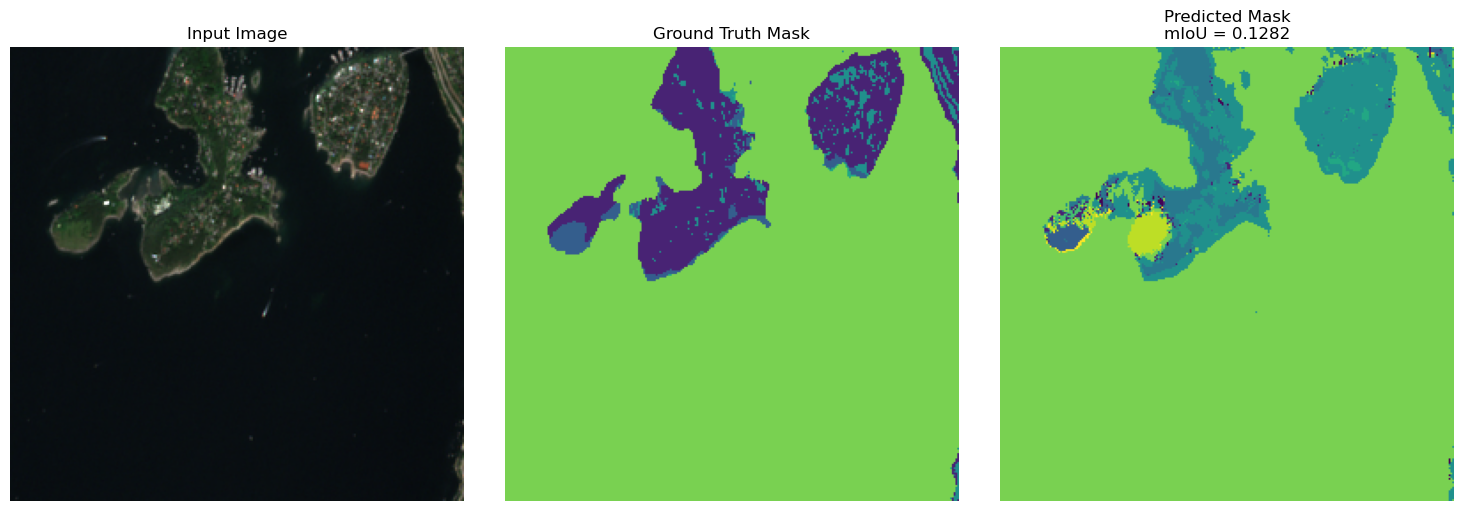

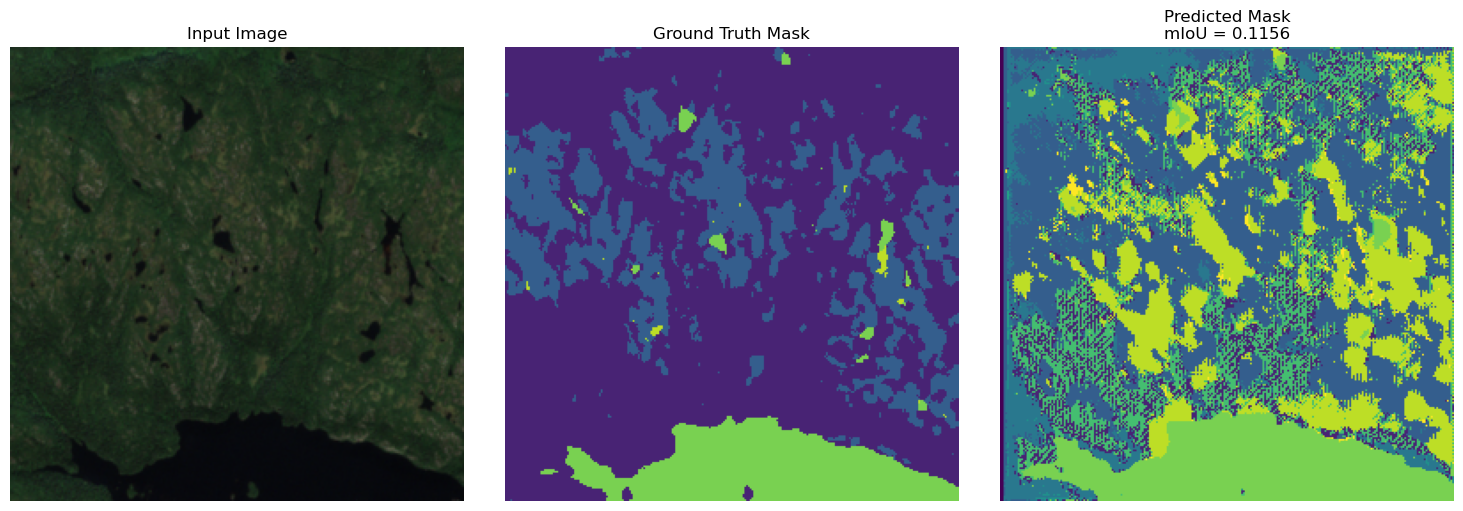

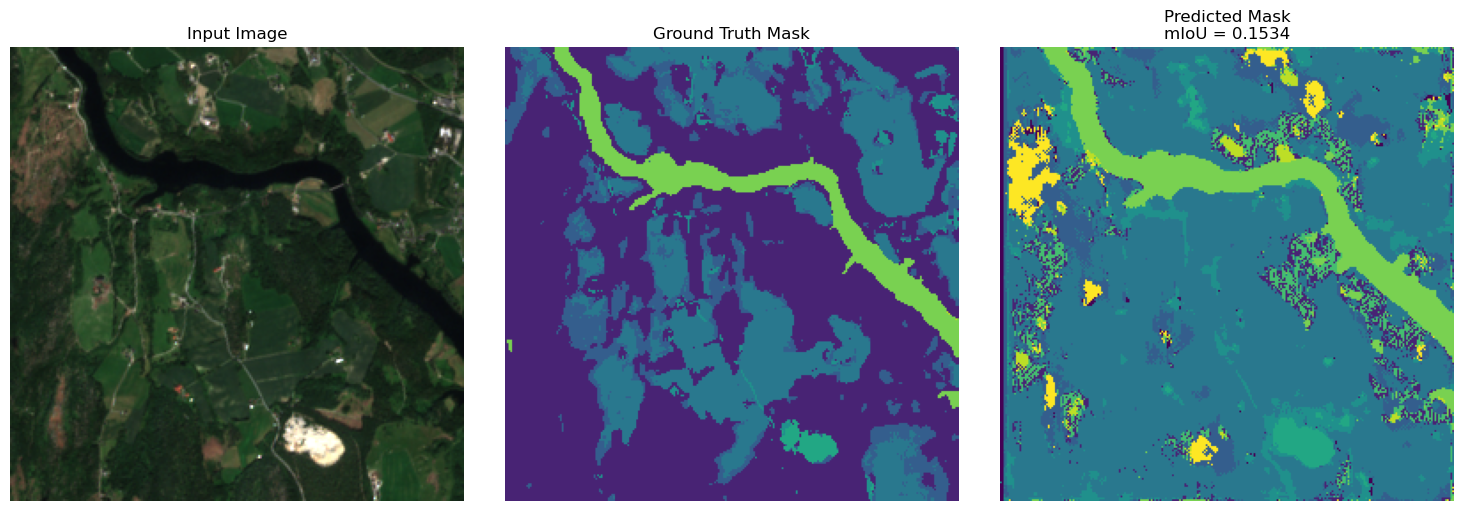

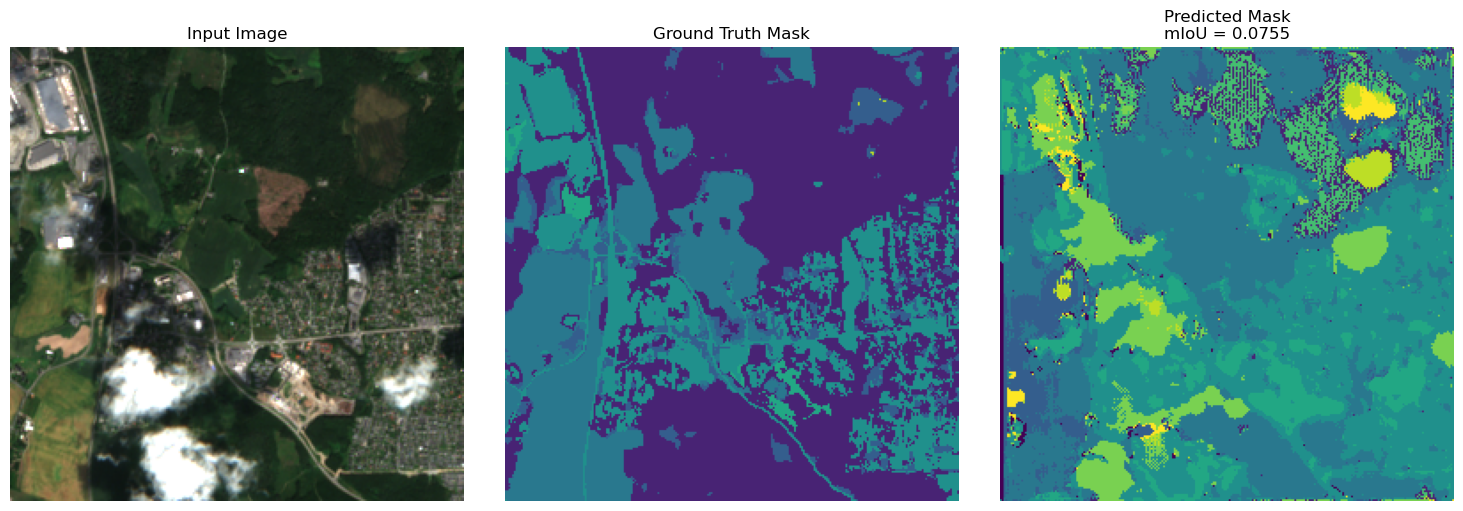

In [19]:
visualize_predictions(model, val_loader, device, classes, num_samples=4)

### Problem 4b Discussion
The predicted masks do a good job in some respects and bad in others. For reference the first three masks do a good job of identifying the water versus land classes. This maybe due to the large contrast between the green of the ground and the almost black of the water. However, as seen in mask 4, the difference between different types of land is much harder for the model to pull out.

### Problem 4c Discussion
I would expect a ResNet backbone to do better than the U-Net that I have implemented. The model could use the pretraining to focus on the differences between the classes of land, rather than just finding the land/water boarders which this model has been shown to do. IoU also helps as it penalizes class imbalance (which has been shown to be significant). If we just did a validation of what pixels "are correct" than the model may just put class 1 down for every pixel as it shows up 70% of the time in the dataset, compared with minority classes.